## Setup

In [2]:
%cd /home/atimans/Desktop/project_erc

/home/atimans/Desktop/project_erc


In [3]:
import sys
sys.path.insert(0, "/home/atimans/Desktop/project_1/erc")

import os
import importlib
import argparse
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from erc.plots.plot_style import *
from erc.util import io_file
from erc.config.cfg_exp import get_cfg_defaults, update_from_args

from erc.exp.exp_ood import set_dirs as set_dirs_ood
from erc.exp.exp_cp import set_dirs as set_dirs_cp
from erc.exp.exp_uci import set_dirs as set_dirs_uci

torch.set_printoptions(sci_mode=False)

In [3]:
os.getcwd()

'/home/atimans/Desktop/project_erc'

In [56]:
def save_fig(fdir, fname):
    full_path = os.path.join(fdir, f"{fname}.png")
    plt.savefig(full_path, format="png", bbox_inches='tight', dpi=800)
    print(f'Figure saved under "{full_path}".')

In [161]:
# FIXED PARAMS

exp = "exp_cp"

args_dict = {
    "cfg_file": "cfg_uci",
    "cfg_dir": f"erc/config/{exp}",
    "exp_suffix": "_FULL",
    "batch_ts": 1,
    "tracker_window": [0, 50, 50],
    "stop_counter": [5, 25, 0],
    "device": "cpu"
}

args = argparse.Namespace(**args_dict)

cfg = get_cfg_defaults()
cfg_exp_file = cfg.PROJECT.CONFIG_FILE if args.cfg_file is None else args.cfg_file
cfg_exp_dir = cfg.PROJECT.CONFIG_DIR if args.cfg_dir is None else args.cfg_dir
cfg_exp = io_file.load_yaml(cfg_exp_file, cfg_exp_dir, to_yacs=True)
cfg.merge_from_other_cfg(cfg_exp)  # override cfg with cfg_exp
cfg, _ = update_from_args(cfg, args)  # override cfg with args
cfg.MODEL.DEVICE = args.device

if exp == "exp_ood":
    cfg = set_dirs_ood(cfg)
elif exp == "exp_cp" and args_dict["cfg_file"] == "cfg_natural":
    cfg = set_dirs_cp(cfg)
elif exp == "exp_cp" and args_dict["cfg_file"] == "cfg_uci":
    cfg = set_dirs_uci(cfg)
else:
    raise ValueError(f"Unknown experiment: {args.exp}")
cfg.freeze()

print(f"\nUsing cfg with experiment path: \n{cfg.RUN.FULL_DIR}")

fig_dir = "plots"
fig_name_prefix = f"{cfg.RUN.SUB_DIR}_{cfg.RUN.EXP_DIR}"
print(f"\nFigures will be saved under: \n{fig_dir}/{fig_name_prefix}_xxx")

Loaded YAML file from erc/config/exp_cp/cfg_uci.yaml into <class 'yacs.config.CfgNode'>.

Using cfg with experiment path: 
../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL

Figures will be saved under: 
plots/uci_cbm_abs_res_12500_erc_0.1_0.1_miscover_ts15000_bts1_tw50_xxx


In [162]:
print(f"\nLoading data from: \n{cfg.RUN.FULL_DIR}")
point_risk = io_file.load_tensor("point_risk", cfg.RUN.FULL_DIR)
running_risk = io_file.load_tensor("running_risk", cfg.RUN.FULL_DIR)
eprocess = io_file.load_tensor("eprocess", cfg.RUN.FULL_DIR)
naive_eprocess = io_file.load_tensor("naive_eprocess", cfg.RUN.FULL_DIR)
pmeb_eprocess = io_file.load_tensor("pmeb_eprocess", cfg.RUN.FULL_DIR)

print(f"\npoint_risk: {point_risk.keys()}")
print(f"running_risk: {running_risk.keys()}")
print(f"eprocess: {eprocess.keys()}")
print(f"naive_eprocess: {naive_eprocess.keys()}")
print(f"pmeb_eprocess: {pmeb_eprocess.keys()}")

point_risk = argparse.Namespace(**point_risk)
running_risk = argparse.Namespace(**running_risk)
eprocess = argparse.Namespace(**eprocess)
naive_eprocess = argparse.Namespace(**naive_eprocess)
pmeb_eprocess = argparse.Namespace(**pmeb_eprocess)

psi_cand = torch.arange(cfg.EXP.PSI_START, cfg.EXP.PSI_END + cfg.EXP.PSI_STEP, cfg.EXP.PSI_STEP)
print("psi_cand:", psi_cand.shape)


Loading data from: 
../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL/point_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL/running_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL/eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL/naive_eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL/pmeb_eprocess.pt.

point_risk: dict_keys(['risk', 'stop_time', 'psi_cs', 'psi_cs_size', 'psi_select', 'fal

## Joint plot

In [163]:
colors = {
    "point_risk": "#0d3b66",
    "running_risk": "#ee964b",
    "eprocess": "#197278",
    "naive_eprocess": "#772e25", # c44536, 772e25, e07a5f, ce4257
    "pmeb_eprocess": "#9f86c0", # 9f86c0, 5e548e
}

In [176]:
psi_cand

tensor([0.0000, 0.0005, 0.0010, 0.0015, 0.0020, 0.0025, 0.0030, 0.0035, 0.0040,
        0.0045, 0.0050, 0.0055, 0.0060, 0.0065, 0.0070, 0.0075, 0.0080, 0.0085,
        0.0090, 0.0095, 0.0100, 0.0105, 0.0110, 0.0115, 0.0120, 0.0125, 0.0130,
        0.0135, 0.0140, 0.0145, 0.0150, 0.0155, 0.0160, 0.0165, 0.0170, 0.0175,
        0.0180, 0.0185, 0.0190, 0.0195, 0.0200, 0.0205, 0.0210, 0.0215, 0.0220,
        0.0225, 0.0230, 0.0235, 0.0240, 0.0245, 0.0250, 0.0255, 0.0260, 0.0265,
        0.0270, 0.0275, 0.0280, 0.0285, 0.0290, 0.0295, 0.0300, 0.0305, 0.0310,
        0.0315, 0.0320, 0.0325, 0.0330, 0.0335, 0.0340, 0.0345, 0.0350, 0.0355,
        0.0360, 0.0365, 0.0370, 0.0375, 0.0380, 0.0385, 0.0390, 0.0395, 0.0400,
        0.0405, 0.0410, 0.0415, 0.0420, 0.0425, 0.0430, 0.0435, 0.0440, 0.0445,
        0.0450, 0.0455, 0.0460, 0.0465, 0.0470, 0.0475, 0.0480, 0.0485, 0.0490,
        0.0495, 0.0500])

In [233]:
psi_select = 0.005
# psi_idx = torch.where(psi_cand == psi_select)[0].item()
psi_idx = 10
print(f"Selected psi: {psi_select} at index {psi_idx}")

Selected psi: 0.005 at index 10


['True Risk $\\hat{\\mathcal{R}}_t$', 'Running Risk $\\hat{\\mathcal{R}}_r$ ($\\bar{\\tau}$=146, 9\\% $>\\delta$))', 'Wealth Process $M_t$ ($\\bar{\\tau}$=394, 0\\% $>\\delta$)', 'Wealth Process $M^{SUM}_t$ ($\\bar{\\tau}$=438, 0\\% $>\\delta$)', 'Wealth Process $M^{EB}_t$ ($\\bar{\\tau}$=1077, 0\\% $>\\delta$)', 'Risk level $\\epsilon$', 'Rejection threshold $1/\\delta$', 'Burn-in period']
Figure saved under "plots/uci_cbm_abs_res_12500_erc_0.1_0.1_miscover_ts15000_bts1_tw50_combined.png".


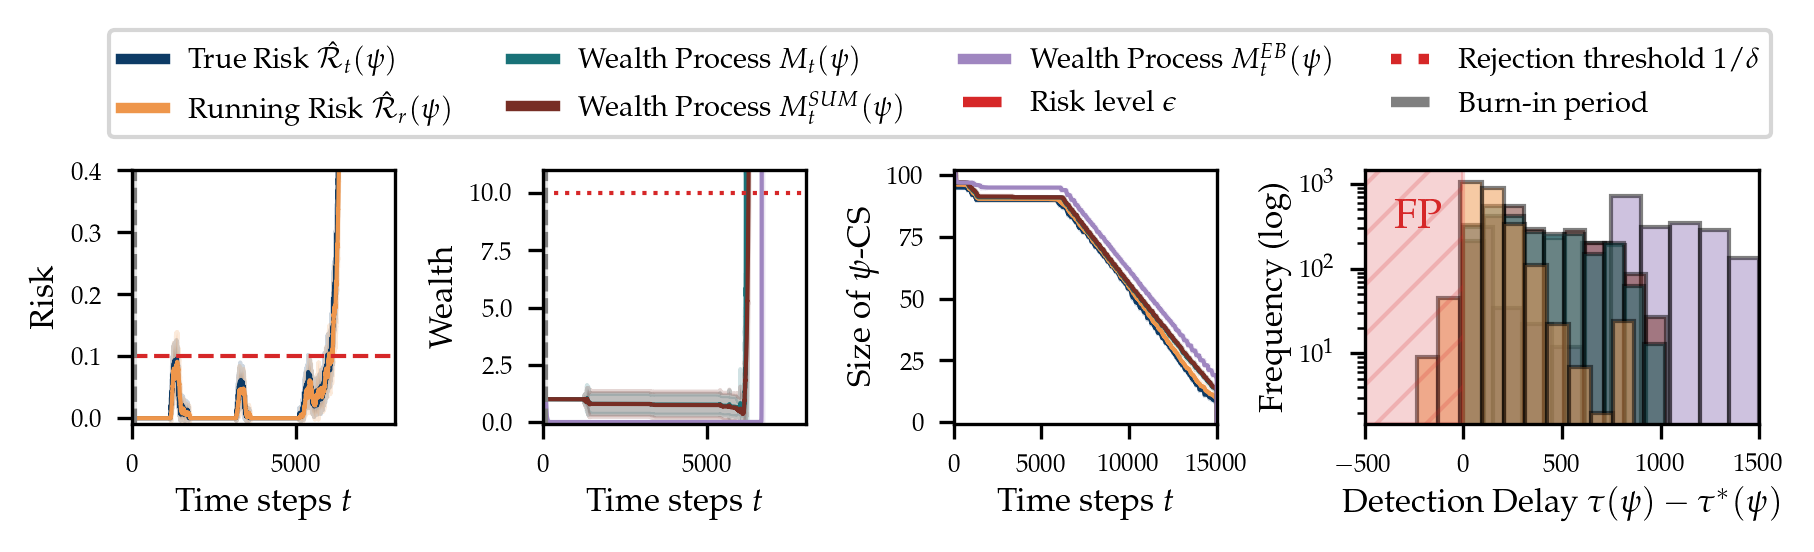

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(7, 1.1), sharex=False, gridspec_kw={'wspace': 0.5, 'width_ratios': [1, 1, 1, 1.5]})

#### FIGURE LIMITS

# x_lim = cfg.EXP.NR_TIMESTEPS
x_lim = 8000

y_lim_risk = cfg.EXP.EPS + 0.3
# y_lim_risk = 1.0 + 0.03

y_lim_wealth = (1 / cfg.EXP.DELTA) + 1

y_lim_psi = len(psi_cand) + 1

################

# First subplot (Risk)
ax = axes[0]
point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

h1 = ax.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                point_risk_mean - point_risk_std, 
                point_risk_mean + point_risk_std, 
                color=colors["point_risk"], alpha=0.2)
h2 = ax.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                running_risk_mean - running_risk_std, 
                running_risk_mean + running_risk_std, 
                color=colors["running_risk"], alpha=0.2)

h3 = ax.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
h4 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel(r"Time steps $t$", labelpad=2)
ax.set_ylabel("Risk", labelpad=2)
ax.set_xlim(0, x_lim)
ax.set_ylim(0 - 0.01, y_lim_risk)
ax.grid(False)

# Second subplot (Wealth)
ax = axes[1]
eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

eprocess_std_stop = np.where(eprocess_mean > (1 / cfg.EXP.DELTA))[0].min() + 50
naive_eprocess_std_stop = np.where(naive_eprocess_mean > (1 / cfg.EXP.DELTA))[0].min() + 50
pmeb_eprocess_std_stop = np.where(pmeb_eprocess_mean > (1 / cfg.EXP.DELTA))[0].min() + 50
# eprocess_std_stop = cfg.EXP.NR_TIMESTEPS
# naive_eprocess_std_stop = cfg.EXP.NR_TIMESTEPS
# pmeb_eprocess_std_stop = cfg.EXP.NR_TIMESTEPS

h5 = ax.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])[0]
ax.fill_between(range(0, eprocess_std_stop), 
                eprocess_mean[:eprocess_std_stop] - eprocess_std[:eprocess_std_stop], 
                eprocess_mean[:eprocess_std_stop] + eprocess_std[:eprocess_std_stop], 
                color=colors["eprocess"], alpha=0.2)
h6 = ax.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])[0]
ax.fill_between(range(0, naive_eprocess_std_stop), 
                naive_eprocess_mean[:naive_eprocess_std_stop] - naive_eprocess_std[:naive_eprocess_std_stop], 
                naive_eprocess_mean[:naive_eprocess_std_stop] + naive_eprocess_std[:naive_eprocess_std_stop], 
                color=colors["naive_eprocess"], alpha=0.2)
h7 = ax.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])[0]
ax.fill_between(range(0, pmeb_eprocess_std_stop), 
                pmeb_eprocess_mean[:pmeb_eprocess_std_stop] - pmeb_eprocess_std[:pmeb_eprocess_std_stop], 
                pmeb_eprocess_mean[:pmeb_eprocess_std_stop] + pmeb_eprocess_std[:pmeb_eprocess_std_stop], 
                color=colors["pmeb_eprocess"], alpha=0.2)

h8 = ax.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
h9 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel(r"Time steps $t$", labelpad=2)
ax.set_ylabel("Wealth", labelpad=2)
ax.set_xlim(0, x_lim)
ax.set_ylim(0 - 0.1, y_lim_wealth)
ax.grid(False)

# Third subplot (Size of Psi-CS)
ax = axes[2]

point_risk_cs_size_mean = point_risk.psi_cs_size.mean(dim=0).numpy()
point_risk_cs_size_std = point_risk.psi_cs_size.std(dim=0).numpy()
running_risk_cs_size_mean = running_risk.psi_cs_size.mean(dim=0).numpy()
running_risk_cs_size_std = running_risk.psi_cs_size.std(dim=0).numpy()
eprocess_cs_size_mean = eprocess.psi_cs_size.mean(dim=0).numpy()
eprocess_cs_size_std = eprocess.psi_cs_size.std(dim=0).numpy()
naive_eprocess_cs_size_mean = naive_eprocess.psi_cs_size.mean(dim=0).numpy()
naive_eprocess_cs_size_std = naive_eprocess.psi_cs_size.std(dim=0).numpy()
pmeb_eprocess_cs_size_mean = pmeb_eprocess.psi_cs_size.mean(dim=0).numpy()
pmeb_eprocess_cs_size_std = pmeb_eprocess.psi_cs_size.std(dim=0).numpy()

ax.plot(point_risk_cs_size_mean, color=colors["point_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 point_risk_cs_size_mean - point_risk_cs_size_std, 
                 point_risk_cs_size_mean + point_risk_cs_size_std, 
                 color=colors["point_risk"], alpha=0.15)
ax.plot(running_risk_cs_size_mean, color=colors["running_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 running_risk_cs_size_mean - running_risk_cs_size_std, 
                 running_risk_cs_size_mean + running_risk_cs_size_std, 
                 color=colors["running_risk"], alpha=0.15)
ax.plot(eprocess_cs_size_mean, color=colors["eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 eprocess_cs_size_mean - eprocess_cs_size_std, 
                 eprocess_cs_size_mean + eprocess_cs_size_std, 
                 color=colors["eprocess"], alpha=0.15)
ax.plot(naive_eprocess_cs_size_mean, color=colors["naive_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 naive_eprocess_cs_size_mean - naive_eprocess_cs_size_std, 
                 naive_eprocess_cs_size_mean + naive_eprocess_cs_size_std, 
                 color=colors["naive_eprocess"], alpha=0.15)
ax.plot(pmeb_eprocess_cs_size_mean, color=colors["pmeb_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 pmeb_eprocess_cs_size_mean - pmeb_eprocess_cs_size_std, 
                 pmeb_eprocess_cs_size_mean + pmeb_eprocess_cs_size_std, 
                 color=colors["pmeb_eprocess"], alpha=0.15)

ax.set_xlabel(r"Time steps $t$", labelpad=2)
ax.set_ylabel(r"Size of $\psi$-CS", labelpad=2)
ax.set_xlim(0, x_lim)
ax.set_ylim(0 - 1, y_lim_psi)
ax.grid(False)

# Fourth subplot (Detection delay + False alarm)
ax = axes[3]

# point_risk_detection_delay = point_risk.detection_delay.flatten().numpy()
running_risk_detection_delay = running_risk.detection_delay.flatten().numpy()
eprocess_detection_delay = eprocess.detection_delay.flatten().numpy()
naive_eprocess_detection_delay = naive_eprocess.detection_delay.flatten().numpy()
pmeb_eprocess_detection_delay = pmeb_eprocess.detection_delay.flatten().numpy()

# point_risk_detection_delay_mean = point_risk_detection_delay.mean()
running_risk_detection_delay_mean = running_risk_detection_delay.mean()
eprocess_detection_delay_mean = eprocess_detection_delay.mean()
naive_eprocess_detection_delay_mean = naive_eprocess_detection_delay.mean()
pmeb_eprocess_detection_delay_mean = pmeb_eprocess_detection_delay.mean()

running_risk_false_alarms_frac = (running_risk.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
eprocess_false_alarms_frac = (eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
naive_eprocess_false_alarms_frac = (naive_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
pmeb_eprocess_false_alarms_frac = (pmeb_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100

# ax.hist(point_risk_detection_delay, bins=10, alpha=0.5, density=False,
#          facecolor=colors["point_risk"], edgecolor='black')
ax.hist(pmeb_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["pmeb_eprocess"], edgecolor='black')
ax.hist(naive_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["naive_eprocess"], edgecolor='black')
ax.hist(eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["eprocess"], edgecolor='black')
ax.hist(running_risk_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["running_risk"], edgecolor='black')

ax.set_xlabel(r"Detection Delay $\tau(\psi) - \tau^{*}(\psi)$", labelpad=2)
ax.set_ylabel("Frequency (log)", labelpad=2)
ax.set_yscale('log')

# TODO: ADJUST HERE
ax.text(-350, 300, 'FP', fontsize=10, fontweight="bold", color='tab:red') 
ax.set_xlim(-500, 1500)
# ax.set_xlim(-1000, 2000)
# ax.set_ylim(0, 1000)

xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, 0, color='tab:red', alpha=0.2, hatch='//')
ax.grid(False)

# Custom legend arrangement
lw = 2.5
legend_handles = [
    Line2D([0, 1], [0, 1], color=colors["point_risk"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["running_risk"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["eprocess"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["naive_eprocess"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["pmeb_eprocess"], linewidth=lw),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle='--', linewidth=lw),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle=':', linewidth=lw),
    Line2D([0, 1], [0, 1], color="grey", linestyle='--', linewidth=lw),
                  ]
legend_labels_text = [
    fr"True Risk $\hat{{\mathcal{{R}}}}_t$",
    fr"Running Risk $\hat{{\mathcal{{R}}}}_r$ ($\bar{{\tau}}$={running_risk_detection_delay_mean:.0f}, {running_risk_false_alarms_frac:.0f}\% $>\delta$))",
    fr"Wealth Process $M_t$ ($\bar{{\tau}}$={eprocess_detection_delay_mean:.0f}, {eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"Wealth Process $M^{{SUM}}_t$ ($\bar{{\tau}}$={naive_eprocess_detection_delay_mean:.0f}, {naive_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"Wealth Process $M^{{EB}}_t$ ($\bar{{\tau}}$={pmeb_eprocess_detection_delay_mean:.0f}, {pmeb_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]
legend_labels = [
    fr"True Risk $\hat{{\mathcal{{R}}}}_t(\psi)$",
    fr"Running Risk $\hat{{\mathcal{{R}}}}_r(\psi)$",
    fr"Wealth Process $M_t(\psi)$",
    fr"Wealth Process $M^{{SUM}}_t(\psi)$",
    fr"Wealth Process $M^{{EB}}_t(\psi)$",
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]

fig.legend(legend_handles, legend_labels, 
           loc='upper center', bbox_to_anchor=(0.51, 1.35), ncol=4,
           handlelength=1.5, handleheight=0.5, fontsize=7)

plt.tight_layout()

print(legend_labels_text)

save_fig(fig_dir, f"{fig_name_prefix}_combined")


In [235]:
raise ValueError("STOP HERE")

ValueError: STOP HERE

## Other joint plots

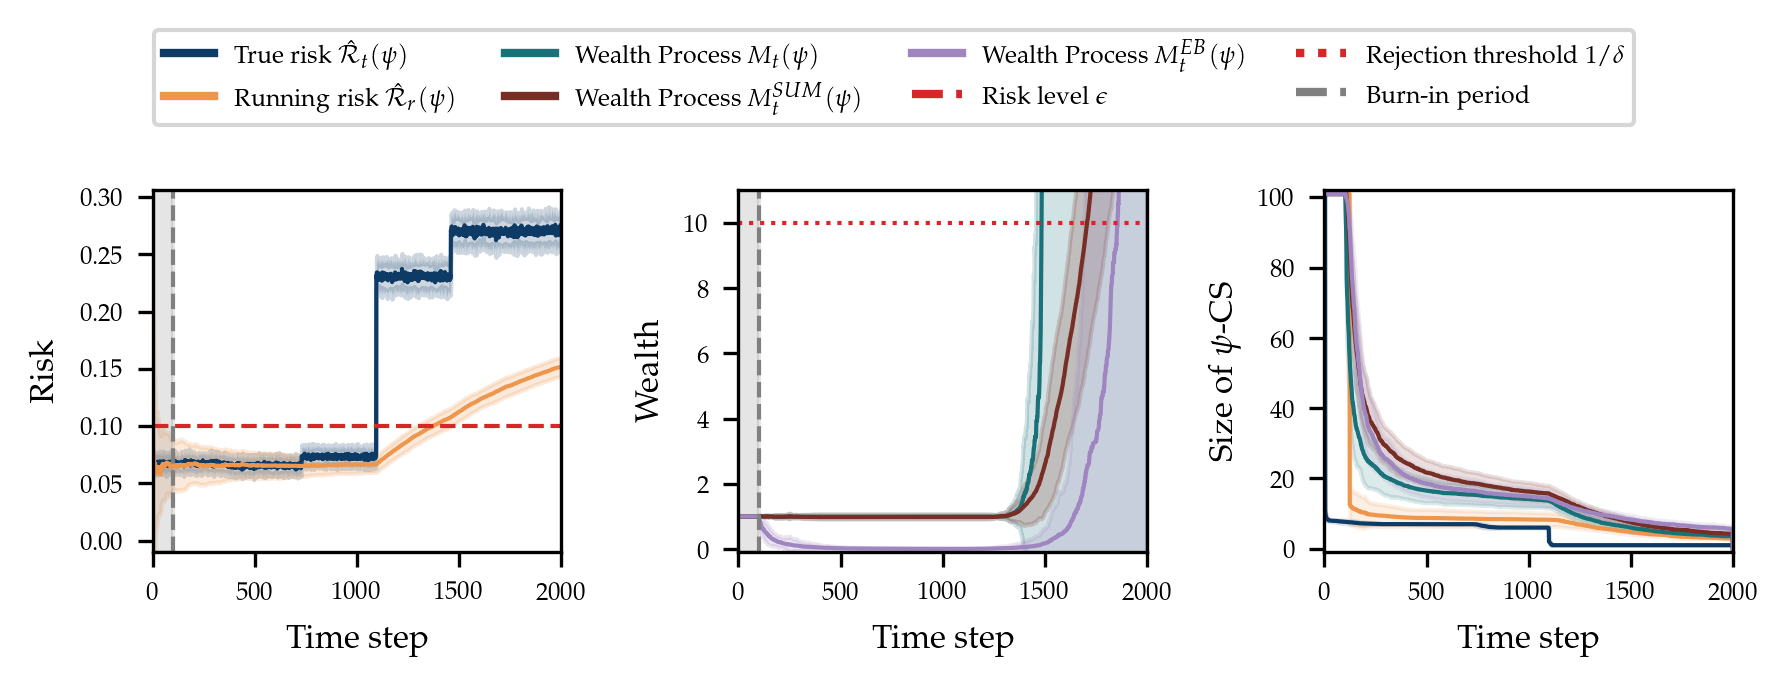

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(6, 1.8), sharex=True)

# First subplot (Risk)
ax = axes[0]
point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

h1 = ax.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                point_risk_mean - point_risk_std, 
                point_risk_mean + point_risk_std, 
                color=colors["point_risk"], alpha=0.2)
h2 = ax.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                running_risk_mean - running_risk_std, 
                running_risk_mean + running_risk_std, 
                color=colors["running_risk"], alpha=0.2)

h3 = ax.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
h4 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Risk")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.01, max(point_risk_mean.max(), running_risk_mean.max()) + 0.03)
ax.grid(False)

# Second subplot (Wealth)
ax = axes[1]
eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

h5 = ax.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                eprocess_mean - eprocess_std, 
                eprocess_mean + eprocess_std, 
                color=colors["eprocess"], alpha=0.2)
h6 = ax.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                naive_eprocess_mean - naive_eprocess_std, 
                naive_eprocess_mean + naive_eprocess_std, 
                color=colors["naive_eprocess"], alpha=0.2)
h7 = ax.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                pmeb_eprocess_mean - pmeb_eprocess_std, 
                pmeb_eprocess_mean + pmeb_eprocess_std, 
                color=colors["pmeb_eprocess"], alpha=0.2)

h8 = ax.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
h9 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Wealth")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.1, (1 / cfg.EXP.DELTA) + 1)
ax.grid(False)

# Third subplot (Size of Psi-CS)
ax = axes[2]

point_risk_cs_size_mean = point_risk.psi_cs_size.mean(dim=0).numpy()
point_risk_cs_size_std = point_risk.psi_cs_size.std(dim=0).numpy()
running_risk_cs_size_mean = running_risk.psi_cs_size.mean(dim=0).numpy()
running_risk_cs_size_std = running_risk.psi_cs_size.std(dim=0).numpy()
eprocess_cs_size_mean = eprocess.psi_cs_size.mean(dim=0).numpy()
eprocess_cs_size_std = eprocess.psi_cs_size.std(dim=0).numpy()
naive_eprocess_cs_size_mean = naive_eprocess.psi_cs_size.mean(dim=0).numpy()
naive_eprocess_cs_size_std = naive_eprocess.psi_cs_size.std(dim=0).numpy()
pmeb_eprocess_cs_size_mean = pmeb_eprocess.psi_cs_size.mean(dim=0).numpy()
pmeb_eprocess_cs_size_std = pmeb_eprocess.psi_cs_size.std(dim=0).numpy()

ax.plot(point_risk_cs_size_mean, color=colors["point_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 point_risk_cs_size_mean - point_risk_cs_size_std, 
                 point_risk_cs_size_mean + point_risk_cs_size_std, 
                 color=colors["point_risk"], alpha=0.15)
ax.plot(running_risk_cs_size_mean, color=colors["running_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 running_risk_cs_size_mean - running_risk_cs_size_std, 
                 running_risk_cs_size_mean + running_risk_cs_size_std, 
                 color=colors["running_risk"], alpha=0.15)
ax.plot(eprocess_cs_size_mean, color=colors["eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 eprocess_cs_size_mean - eprocess_cs_size_std, 
                 eprocess_cs_size_mean + eprocess_cs_size_std, 
                 color=colors["eprocess"], alpha=0.15)
ax.plot(naive_eprocess_cs_size_mean, color=colors["naive_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 naive_eprocess_cs_size_mean - naive_eprocess_cs_size_std, 
                 naive_eprocess_cs_size_mean + naive_eprocess_cs_size_std, 
                 color=colors["naive_eprocess"], alpha=0.15)
ax.plot(pmeb_eprocess_cs_size_mean, color=colors["pmeb_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 pmeb_eprocess_cs_size_mean - pmeb_eprocess_cs_size_std, 
                 pmeb_eprocess_cs_size_mean + pmeb_eprocess_cs_size_std, 
                 color=colors["pmeb_eprocess"], alpha=0.15)

ax.set_xlabel("Time step")
ax.set_ylabel(r"Size of $\psi$-CS")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 1, len(psi_cand) + 1)
ax.grid(False)

# Custom legend arrangement
legend_handles = [
    Line2D([0, 1], [0, 1], color=colors["point_risk"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["running_risk"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["eprocess"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["naive_eprocess"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["pmeb_eprocess"], linewidth=2),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle='--', linewidth=2),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle=':', linewidth=2),
    Line2D([0, 1], [0, 1], color="grey", linestyle='--', linewidth=2),
                  ]
legend_labels = [
    fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$",
    fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$",
    fr"Wealth Process $M_t(\psi)$",
    fr"Wealth Process $M^{{SUM}}_t(\psi)$",
    fr"Wealth Process $M^{{EB}}_t(\psi)$",
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]

fig.legend(legend_handles, legend_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=4,
           handlelength=2, handleheight=1)
plt.tight_layout()

# save_fig(fig_dir, f"{fig_name_prefix}_combined")


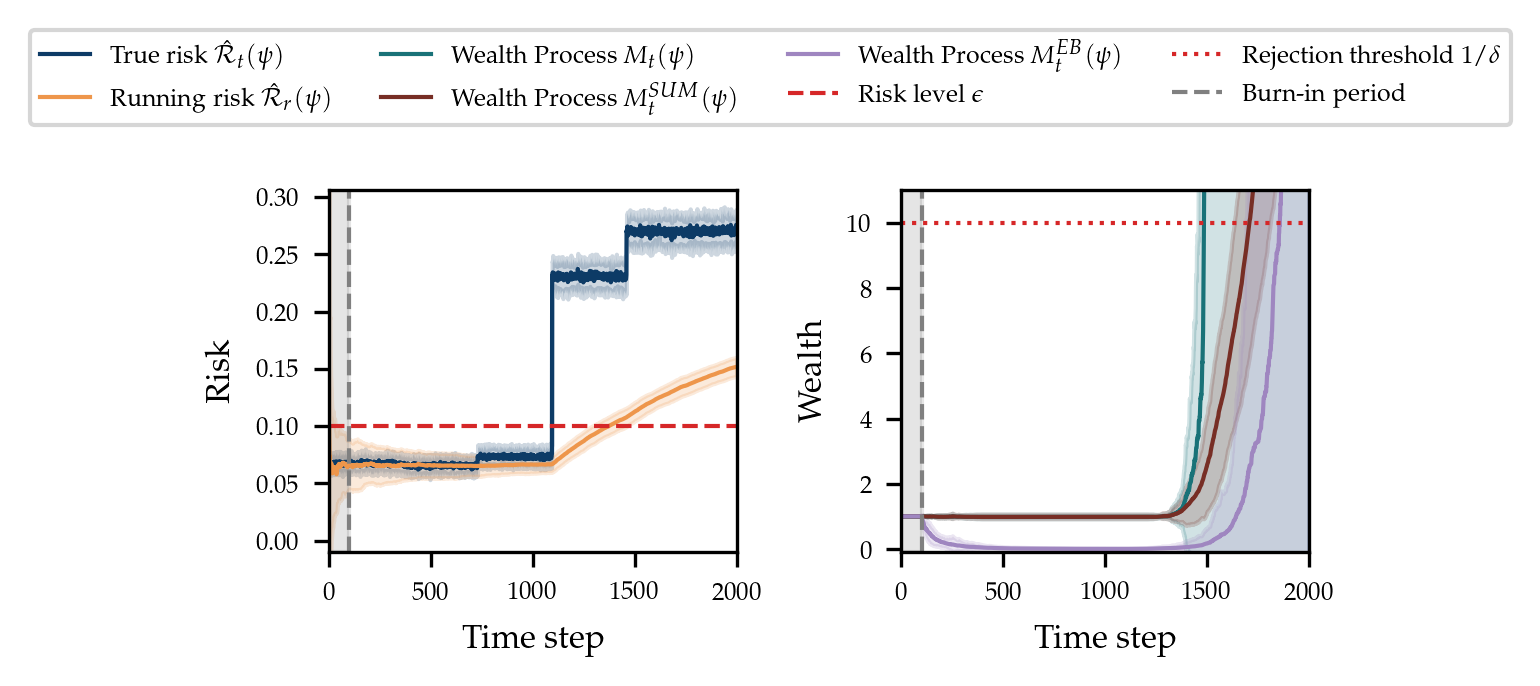

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(4, 1.8), sharex=True)

# First subplot (Risk)
ax = axes[0]
point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

h1 = ax.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                point_risk_mean - point_risk_std, 
                point_risk_mean + point_risk_std, 
                color=colors["point_risk"], alpha=0.2)
h2 = ax.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                running_risk_mean - running_risk_std, 
                running_risk_mean + running_risk_std, 
                color=colors["running_risk"], alpha=0.2)

h3 = ax.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
h4 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Risk")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.01, max(point_risk_mean.max(), running_risk_mean.max()) + 0.03)
ax.grid(False)

# Second subplot (Wealth)
ax = axes[1]
eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

h5 = ax.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                eprocess_mean - eprocess_std, 
                eprocess_mean + eprocess_std, 
                color=colors["eprocess"], alpha=0.2)
h6 = ax.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                naive_eprocess_mean - naive_eprocess_std, 
                naive_eprocess_mean + naive_eprocess_std, 
                color=colors["naive_eprocess"], alpha=0.2)
h7 = ax.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                pmeb_eprocess_mean - pmeb_eprocess_std, 
                pmeb_eprocess_mean + pmeb_eprocess_std, 
                color=colors["pmeb_eprocess"], alpha=0.2)

h8 = ax.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
h9 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Wealth")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.1, (1 / cfg.EXP.DELTA) + 1)
ax.grid(False)

# Custom legend arrangement
first_row_handles = [h1, h2, h5, h6, h7]  # Methods
first_row_labels = [
    fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$",
    fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$",
    fr"Wealth Process $M_t(\psi)$",
    fr"Wealth Process $M^{{SUM}}_t(\psi)$",
    fr"Wealth Process $M^{{EB}}_t(\psi)$"
]

second_row_handles = [h3, h8, h4]  # Other elements
second_row_labels = [
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]

# Create a joint legend with two rows
fig.legend(first_row_handles + second_row_handles, first_row_labels + second_row_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=4)

plt.tight_layout()
# save_fig(fig_dir, f"{fig_name_prefix}_combined")

## Other single plots

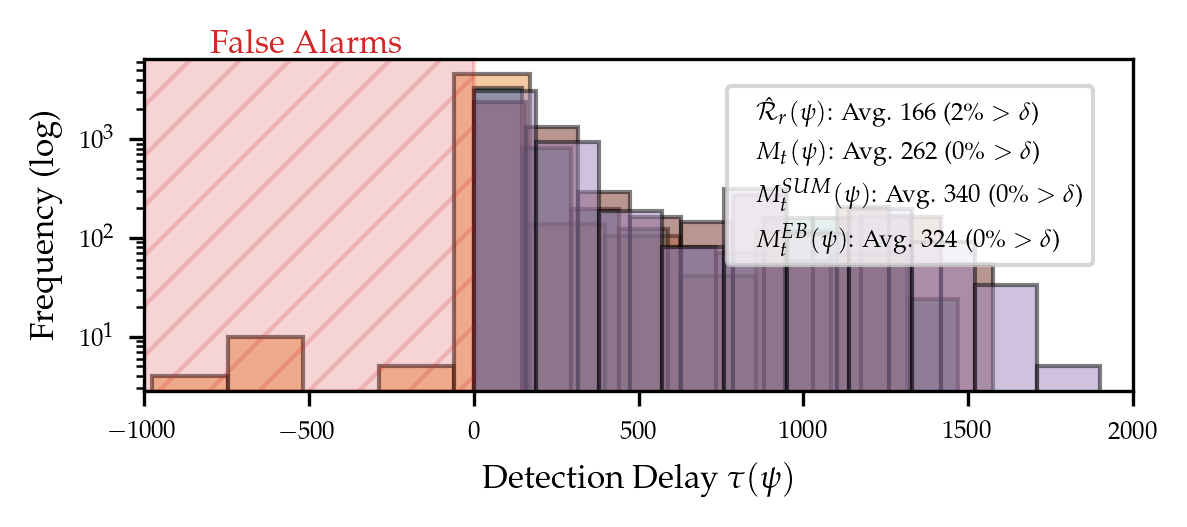

In [ ]:
fig, ax = plt.subplots(figsize=(4, 1.8))

# point_risk_detection_delay = point_risk.detection_delay.flatten().numpy()
running_risk_detection_delay = running_risk.detection_delay.flatten().numpy()
eprocess_detection_delay = eprocess.detection_delay.flatten().numpy()
naive_eprocess_detection_delay = naive_eprocess.detection_delay.flatten().numpy()
pmeb_eprocess_detection_delay = pmeb_eprocess.detection_delay.flatten().numpy()

# point_risk_detection_delay_mean = point_risk_detection_delay.mean()
running_risk_detection_delay_mean = running_risk_detection_delay.mean()
eprocess_detection_delay_mean = eprocess_detection_delay.mean()
naive_eprocess_detection_delay_mean = naive_eprocess_detection_delay.mean()
pmeb_eprocess_detection_delay_mean = pmeb_eprocess_detection_delay.mean()

running_risk_false_alarms_frac = (running_risk.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
eprocess_false_alarms_frac = (eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
naive_eprocess_false_alarms_frac = (naive_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
pmeb_eprocess_false_alarms_frac = (pmeb_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100

# ax.hist(point_risk_detection_delay, bins=10, alpha=0.5, density=False,
#          facecolor=colors["point_risk"], edgecolor='black')
ax.hist(running_risk_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["running_risk"], edgecolor='black')
ax.hist(eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["eprocess"], edgecolor='black')
ax.hist(naive_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["naive_eprocess"], edgecolor='black')
ax.hist(pmeb_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["pmeb_eprocess"], edgecolor='black')

ax.text(-800, 7500, 'False Alarms', fontsize=8, color='tab:red')
ax.set_xlabel(r"Detection Delay $\tau(\psi)$")
ax.set_ylabel("Frequency")
ax.set_yscale('log')
ax.set_xlim(-1000, 2000)
# ax.set_ylim(0, 1000)
xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, 0, color='tab:red', alpha=0.2, hatch='//')
ax.grid(False)

# Custom legend arrangement
legend_handles = [
    Line2D([0, 1], [0, 1], color=colors["running_risk"], linewidth=1),
    Line2D([0, 1], [0, 1], color=colors["eprocess"], linewidth=1),
    Line2D([0, 1], [0, 1], color=colors["naive_eprocess"], linewidth=1),
    Line2D([0, 1], [0, 1], color=colors["pmeb_eprocess"], linewidth=1),
                  ]
legend_labels = [
    fr"$\hat{{\mathcal{{R}}}}_r(\psi)$: Avg. {running_risk_detection_delay_mean:.0f} ({running_risk_false_alarms_frac:.0f}\% $>\delta$)",
    fr"$M_t(\psi)$: Avg. {eprocess_detection_delay_mean:.0f} ({eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"$M^{{SUM}}_t(\psi)$: Avg. {naive_eprocess_detection_delay_mean:.0f} ({naive_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"$M^{{EB}}_t(\psi)$: Avg. {pmeb_eprocess_detection_delay_mean:.0f} ({pmeb_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
]

fig.legend(legend_handles, legend_labels, 
           bbox_to_anchor=(0.6, 0.85),
           loc='upper left', handlelength=0)
fig.tight_layout()


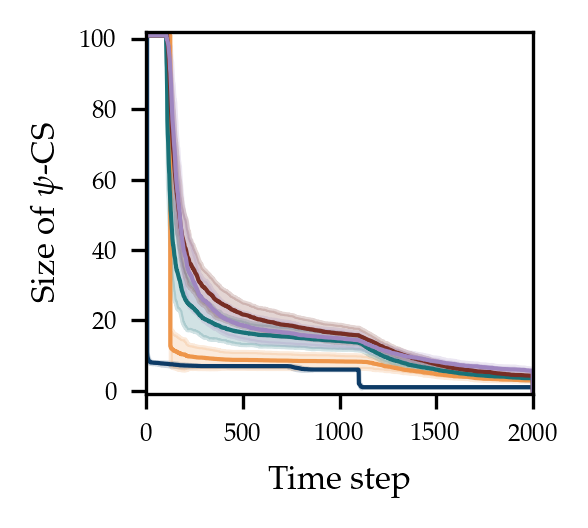

In [ ]:
plt.figure(figsize=(2, 1.8))

point_risk_cs_size_mean = point_risk.psi_cs_size.mean(dim=0)
point_risk_cs_size_std = point_risk.psi_cs_size.std(dim=0)
running_risk_cs_size_mean = running_risk.psi_cs_size.mean(dim=0)
running_risk_cs_size_std = running_risk.psi_cs_size.std(dim=0)
eprocess_cs_size_mean = eprocess.psi_cs_size.mean(dim=0)
eprocess_cs_size_std = eprocess.psi_cs_size.std(dim=0)
naive_eprocess_cs_size_mean = naive_eprocess.psi_cs_size.mean(dim=0)
naive_eprocess_cs_size_std = naive_eprocess.psi_cs_size.std(dim=0)
pmeb_eprocess_cs_size_mean = pmeb_eprocess.psi_cs_size.mean(dim=0)
pmeb_eprocess_cs_size_std = pmeb_eprocess.psi_cs_size.std(dim=0)

plt.plot(point_risk_cs_size_mean, color=colors["point_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 point_risk_cs_size_mean - point_risk_cs_size_std, 
                 point_risk_cs_size_mean + point_risk_cs_size_std, 
                 color=colors["point_risk"], alpha=0.2)
plt.plot(running_risk_cs_size_mean, color=colors["running_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 running_risk_cs_size_mean - running_risk_cs_size_std, 
                 running_risk_cs_size_mean + running_risk_cs_size_std, 
                 color=colors["running_risk"], alpha=0.2)
plt.plot(eprocess_cs_size_mean, color=colors["eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 eprocess_cs_size_mean - eprocess_cs_size_std, 
                 eprocess_cs_size_mean + eprocess_cs_size_std, 
                 color=colors["eprocess"], alpha=0.2)
plt.plot(naive_eprocess_cs_size_mean, color=colors["naive_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 naive_eprocess_cs_size_mean - naive_eprocess_cs_size_std, 
                 naive_eprocess_cs_size_mean + naive_eprocess_cs_size_std, 
                 color=colors["naive_eprocess"], alpha=0.2)
plt.plot(pmeb_eprocess_cs_size_mean, color=colors["pmeb_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 pmeb_eprocess_cs_size_mean - pmeb_eprocess_cs_size_std, 
                 pmeb_eprocess_cs_size_mean + pmeb_eprocess_cs_size_std, 
                 color=colors["pmeb_eprocess"], alpha=0.2)

plt.xlabel("Time step")
plt.ylabel(r"Size of $\psi$-CS")
plt.xlim(0, cfg.EXP.NR_TIMESTEPS)
plt.ylim(0 - 1, len(psi_cand) + 1)
plt.grid(False)

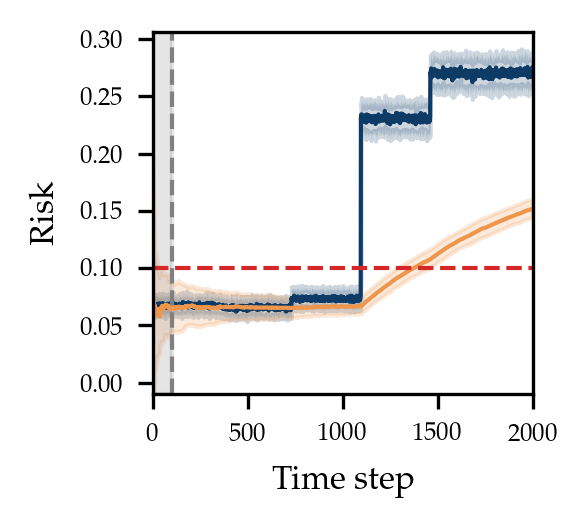

In [ ]:
plt.figure(figsize=(2, 1.8))

point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

plt.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    point_risk_mean - point_risk_std, 
                    point_risk_mean + point_risk_std,
                    color=colors["point_risk"],
                    alpha=0.2)
plt.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    running_risk_mean - running_risk_std, 
                    running_risk_mean + running_risk_std, 
                    color=colors["running_risk"],
                    alpha=0.2)

plt.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
plt.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
plt.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

# eps_upper = 1.0
eps_upper = max(point_risk_mean.max(), running_risk_mean.max())

plt.xlabel("Time step")
plt.ylabel("Risk")
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
plt.xlim(0, cfg.EXP.NR_TIMESTEPS)
plt.ylim(0 - 0.01, eps_upper + 0.03)
plt.grid(False)

# save_fig(fig_dir, f"{fig_name_ prefix}_risk")

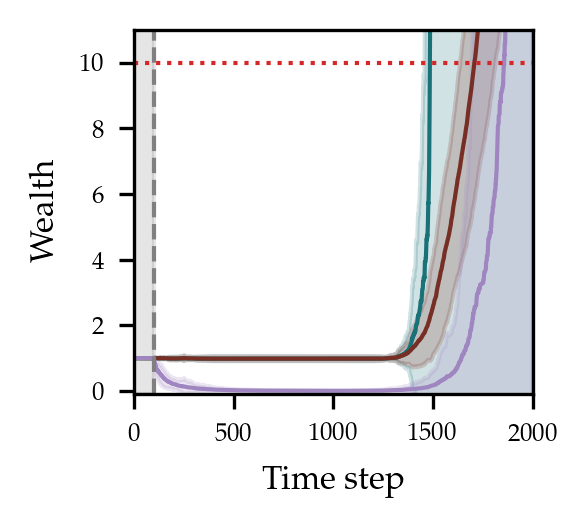

In [ ]:
plt.figure(figsize=(2, 1.8))

eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

plt.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    eprocess_mean - eprocess_std, 
                    eprocess_mean + eprocess_std, 
                    color=colors["eprocess"],
                    alpha=0.2)
plt.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    naive_eprocess_mean - naive_eprocess_std, 
                    naive_eprocess_mean + naive_eprocess_std,
                    color=colors["naive_eprocess"],
                    alpha=0.2)
plt.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    pmeb_eprocess_mean - pmeb_eprocess_std, 
                    pmeb_eprocess_mean + pmeb_eprocess_std,
                    color=colors["pmeb_eprocess"], 
                    alpha=0.2)

plt.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
plt.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
plt.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

wealth_upper = (1 / cfg.EXP.DELTA)

plt.xlabel("Time step")
plt.ylabel("Wealth")
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=5)
plt.xlim(0, cfg.EXP.NR_TIMESTEPS)
plt.ylim(0 - 0.1, wealth_upper + 1)
plt.grid(False)

# save_fig(fig_dir, f"{fig_name_prefix}_wealth")

## Results params table

In [ ]:
paths = [
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw0_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw0_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw0_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw200_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw200_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw200_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw50_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw50_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw50_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw10_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw10_FULL",
    "../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw10_FULL"
]

In [ ]:
paths = []
base_path, filename = cfg.RUN.FULL_DIR.rsplit('/', 1)
bts_fn, tw_fn = filename.split("_")[-4], filename.split("_")[-2]

nr_bs = [1, 10, 50]
nr_tw = [0, 200, 50, 10]

for tw in [f"tw{t}" for t in nr_tw]:
    for bts in [f"bts{b}" for b in nr_bs]:
        paths.append(
            os.path.join(base_path, filename.replace(bts_fn, bts).replace(tw_fn, tw))
        )
        print(paths[-1])

../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts1_ots200_tw0_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts10_ots200_tw0_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts50_ots200_tw0_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts1_ots200_tw200_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts10_ots200_tw200_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts50_ots200_tw200_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_ts1500_bts1_ots200_tw50_FULL
../../../../media/atimans/hdd/output_erc/exp_ood/resnet50_cifar10_svhn_entropy/erc_0.1_0.1_fpr_fnr_t

In [ ]:
data_delay = torch.zeros((len(paths), 4, 2))
data_fp = torch.zeros((len(paths), 4, 2))

for p, path in tqdm(enumerate(paths), desc="Paths"):
    # point_risk = io_file.load_tensor("point_risk", path)
    running_risk = io_file.load_tensor("running_risk", path)
    eprocess = io_file.load_tensor("eprocess", path)
    naive_eprocess = io_file.load_tensor("naive_eprocess", path)
    pmeb_eprocess = io_file.load_tensor("pmeb_eprocess", path)
    
    # point_risk = argparse.Namespace(**point_risk)
    running_risk = argparse.Namespace(**running_risk)
    eprocess = argparse.Namespace(**eprocess)
    naive_eprocess = argparse.Namespace(**naive_eprocess)
    pmeb_eprocess = argparse.Namespace(**pmeb_eprocess)
    
    for m, method in enumerate([running_risk, eprocess, naive_eprocess, pmeb_eprocess]):
        data_delay[p, m, 0] = method.detection_delay.mean()
        data_delay[p, m, 1] = method.detection_delay.std()
        data_fp[p, m, 0] = (method.false_alarms.mean(dim=0) > 0).to(torch.float).mean() * 100
        data_fp[p, m, 1] = (method.false_alarms.mean(dim=0) > cfg.EXP.DELTA).to(torch.float).mean() * 100
    
    del running_risk, eprocess, naive_eprocess, pmeb_eprocess

Paths: 0it [00:00, ?it/s]

Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw0_FULL/running_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw0_FULL/eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw0_FULL/naive_eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts1_tw0_FULL/pmeb_eprocess.pt.


Paths: 1it [00:21, 21.11s/it]

Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw0_FULL/running_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw0_FULL/eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw0_FULL/naive_eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw0_FULL/pmeb_eprocess.pt.


Paths: 2it [00:41, 20.85s/it]

...

Paths: 10it [03:16, 19.05s/it]

Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw10_FULL/running_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw10_FULL/eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw10_FULL/naive_eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts10_tw10_FULL/pmeb_eprocess.pt.


Paths: 11it [03:35, 19.05s/it]

Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw10_FULL/running_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw10_FULL/eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw10_FULL/naive_eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/uci_cbm_abs_res_12500/erc_0.1_0.1_miscover_ts15000_bts50_tw10_FULL/pmeb_eprocess.pt.


Paths: 12it [03:56, 19.70s/it]


In [ ]:
data_delay[0], data_delay.shape

(tensor([[1373.1417,  952.0264],
         [1415.9897,  956.7932],
         [1469.1136,  970.7751],
         [3526.6328, 2193.4822]]),
 torch.Size([12, 4, 2]))

In [ ]:
from itertools import product

all_tw_bts = list(product(nr_tw, nr_bs))
print(all_tw_bts)


[(0, 1), (0, 10), (0, 50), (200, 1), (200, 10), (200, 50), (50, 1), (50, 10), (50, 50), (10, 1), (10, 10), (10, 50)]


In [ ]:
df = pd.DataFrame()

# Custom float format function
def custom_format(x):
    if x in [0.0]:
        return x
    else:
        return '{:.2f}'.format(x)

with open(f'{fig_dir}/cp_uci_bts_tw_res_latex.txt', 'w') as f:
    
    for i, (tw, bts) in enumerate(all_tw_bts):
        row_data = {"tw": tw, "bts": bts}
        row_str = f"{tw} & {bts}"
        
        for m, method in enumerate(["running_risk", "eprocess", "naive_eprocess", "pmeb_eprocess"]):
            row_delay = f"${data_delay[i, m, 0]:.0f} \pm \scriptstyle {data_delay[i, m, 1]:.0f}$"
            row_fp = f"{data_fp[i, m, 0]:.2f}\% & {data_fp[i, m, 1]:.2f}\%"
            
            row_data[f"bts{bts}_{method}"] = f"{row_delay} & {row_fp}"
            row_str += f" & {row_delay} & {row_fp}"
            
        df = df.append(row_data, ignore_index=True)
        f.write(row_str + " \\\\\n")

df.to_csv(f'{fig_dir}/cp_uci_bts_tw_res_table.csv', index=False, float_format=custom_format)

## Illustration Example

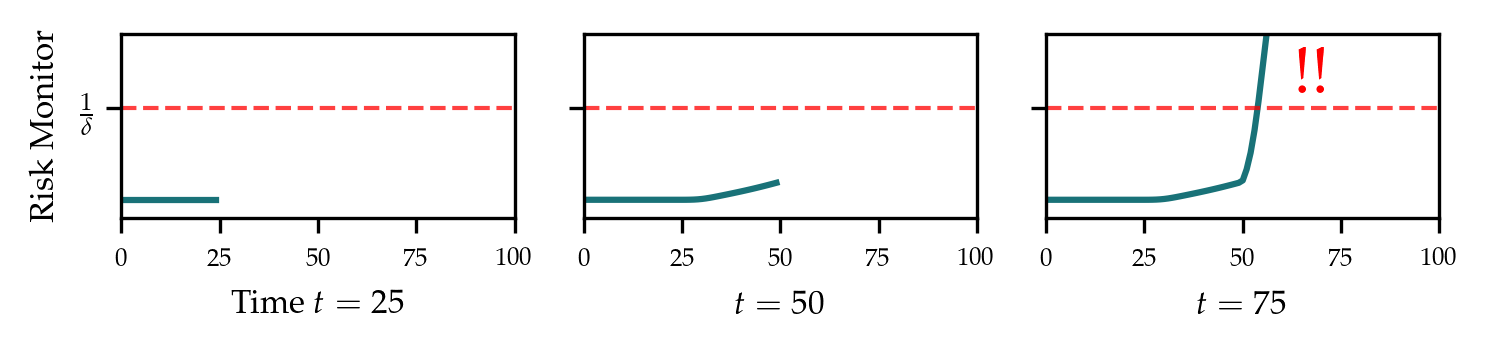

In [ ]:
x = np.arange(100)
x_plot = [25, 50, 75]
# monitor = [
#     np.concatenate([np.ones(25), np.zeros(75)]),
#     np.concatenate([np.ones(50), np.zeros(50)]),
#     np.concatenate([np.ones(50), np.exp(np.linspace(0, 4, 50))])
# ]

t = np.arange(100)
def smooth_transition(start, end, curve, t, width=10):
    blend = 1 / (1 + np.exp(-0.5 * (t - start - width/2)))  # sigmoid centered at start+width/2
    return (1 - blend) * 1 + blend * curve

monitor_0 = np.concatenate([np.ones(25), np.zeros(75)])

subexp_growth = 1 + 5 * (np.linspace(0, 1, 75) ** 1.5)  # gentle increase
monitor_1 = np.concatenate([
    np.ones(25),
    smooth_transition(25, 50, subexp_growth[:25], t[25:50]),
    np.zeros(50)
])

strong_exp = np.exp(np.linspace(2.7, 2.8, 25))  # fast exponential
monitor_2 = np.concatenate([
    np.ones(25),
    smooth_transition(25, 50, subexp_growth[:25], t[25:50]),
    smooth_transition(50, 75, strong_exp, t[50:75]),
    np.zeros(25)
])

monitor = [monitor_0, monitor_1, monitor_2]

threshold = 6

# Create figure with subplots
fig, axs = plt.subplots(1, 3, figsize=(5, 1.2), sharey=True)

for i, ax in enumerate(axs):
    ax.plot(x[:x_plot[i]], monitor[i][:x_plot[i]], color='#197278', lw=1.5)
    ax.plot(x[x_plot[i]:], monitor[i][x_plot[i]:], color='white', lw=1.5)
    # ax.plot(x, monitor[i], color='#197278', lw=1.5)
    
    ax.axhline(threshold, color='red', linestyle='--', alpha=0.75)
    ax.set_xlim([0, 100])
    ax.set_ylim([0, 10])
    ax.set_xlabel(rf"$t={x_plot[i]}$")
    ax.grid(False)
    
    ax.set_yticks([threshold])
    ax.set_yticklabels([r"$\frac{1}{\delta}$"], fontsize=8)
    ax.set_xticks([0, 25, 50, 75, 100])
    
    if i == 0:
        ax.set_ylabel("Risk Monitor")
        ax.set_xlabel(rf"Time $t={x_plot[i]}$")
    
    if np.any(monitor[i] > threshold):
        idx = np.argmax(monitor[i] > threshold)
        ax.text(x[idx] + 10, monitor[i][idx] + 0.5, '!!', fontsize=16, color='red', fontweight='bold')

plt.tight_layout()
# plt.savefig("plots/example_monitoring.png", format="png", bbox_inches='tight', dpi=2000)
